In [113]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [180]:
from pathlib import Path

import awkward as ak
import numpy as np
import pandas as pd
import uproot
from uncertainties import unumpy as unp

from utils.fit import Fit
from utils.helpers import (
    create_unique_event_id,
    get_migration_matrix,
    get_str_fraction,
    plot_migration_matrix,
    plot_rho_scan,
    plot_values,
    rho_scan,
    setup_env,
    setup_plot_style,
)

In [115]:
setup_plot_style()
setup_env()

In [116]:
reco_vars = [
    "run",
    "eventID",
    "longTracks",
    "Track_x0",
    "Track_y0",
    "Track_ThetaX_atVetoNu",
    "Track_ThetaY_atVetoNu",
    "Track_r_atMaxRadius",
    "Track_nDoF",
    "Track_nLayers",
    "Track_Chi2",
    "Track_charge",
    "Track_pz0",
    "t_pz",
    "t_st1_pz",
]

truth_vars = [
    "run",
    "eventID",
    "truth_pdg",
    "truth_prod_x",
    "truth_prod_y",
    "truth_prod_z",
    "truth_px",
    "truth_py",
    "truth_pz",
]

In [117]:
reco_query = (
    "(longTracks == 1) & (abs(Track_x0) < 50.0) & (abs(Track_y0) < 50.0)"
    " & (abs(Track_ThetaX_atVetoNu) < 10e-3) & (abs(Track_ThetaY_atVetoNu) < 10e-3)"
    " & (Track_r_atMaxRadius < 90) & (Track_nDoF > 9) & (Track_nLayers >= 7)"
    " & (chi2_ndof < 3.0)"
)

truth_query = (
    "(abs(truth_prod_x) < 50) & (abs(truth_prod_y) < 50)"
    " & (abs(truth_tan_theta_x) < 10e-3) & (abs(truth_tan_theta_y) < 10e-3)"
)

In [118]:
def get_df(path: Path) -> pd.DataFrame:
    MeV_to_GeV = 1e-3
    reco_df = ak.to_dataframe(
        uproot.open(path)["nt"].arrays(reco_vars, library="ak"), how="outer"
    )
    reco_df["eventID"] = create_unique_event_id(reco_df["eventID"])
    reco_df["chi2_ndof"] = reco_df["Track_Chi2"] / reco_df["Track_nDoF"]
    reco_df["Track_pz_gev"] = reco_df["Track_pz0"] * MeV_to_GeV
    reco_df["Track_qop"] = reco_df["Track_charge"] / reco_df["Track_pz_gev"]
    reco_df = reco_df.query(reco_query)

    truth_df = ak.to_dataframe(
        uproot.open(path)["nt"].arrays(truth_vars, library="ak"), how="outer"
    )
    # Dataframe contains first 10 truth particles, including secondary electron-positron
    # pairs if the muon interacts. Select only primary muon.
    truth_df = truth_df.query(
        "(abs(truth_pdg) == 13) & (abs(truth_prod_z + 3990) < 1e-3)"
    )
    truth_df["eventID"] = create_unique_event_id(truth_df["eventID"])
    # Create auxilary variables
    truth_df["truth_tan_theta_x"] = truth_df["truth_px"] / truth_df["truth_pz"]
    truth_df["truth_tan_theta_y"] = truth_df["truth_py"] / truth_df["truth_pz"]
    truth_df["truth_pz_gev"] = truth_df["truth_pz"] * MeV_to_GeV
    truth_df["truth_charge"] = np.where(truth_df["truth_pdg"] == 13, -1, 1)
    truth_df["truth_qop"] = truth_df["truth_charge"] / truth_df["truth_pz_gev"]
    # Apply event selection
    truth_df = truth_df.query(truth_query)

    mu_df = pd.merge(truth_df, reco_df, on="eventID", how="outer")

    assert_msg = "Found reco event without matching truth event"
    assert len(mu_df.query("truth_pdg.isna()")) == 0, assert_msg

    return mu_df

# Main


## Read data


In [119]:
qop_bins = np.load("data/qop_bins.npy")
momentum_bins = np.load("data/momentum_bins.npy")

In [120]:
muon_dir = Path("/Users/tboeckh/Downloads")
mu_minus_path = muon_dir / "result_100047_track_cut.root"
mu_plus_path = muon_dir / "result_100048_track_cut.root"

mu_minus_df = get_df(mu_minus_path)
mu_plus_df = get_df(mu_plus_path)
mu_df = pd.concat([mu_minus_df, mu_plus_df])

mu_flux = np.load("data/mu_flux.npy", allow_pickle=True)

In [121]:
truth_label = r"$q/p_{\mathsf{truth}}$ [GeV]"
reco_label = r"$q/p_{\mathsf{reco}}$ [GeV]"
truth_var = "truth_qop"
reco_var = "Track_qop"
edges = qop_bins
centers = 0.5 * (edges[1:] + edges[:-1])
num_bins = len(centers)

## Migration Matrix


In [122]:
mu_mig = get_migration_matrix(
    df=mu_df,
    truth_var=truth_var,
    reco_var=reco_var,
    edges=qop_bins,
)

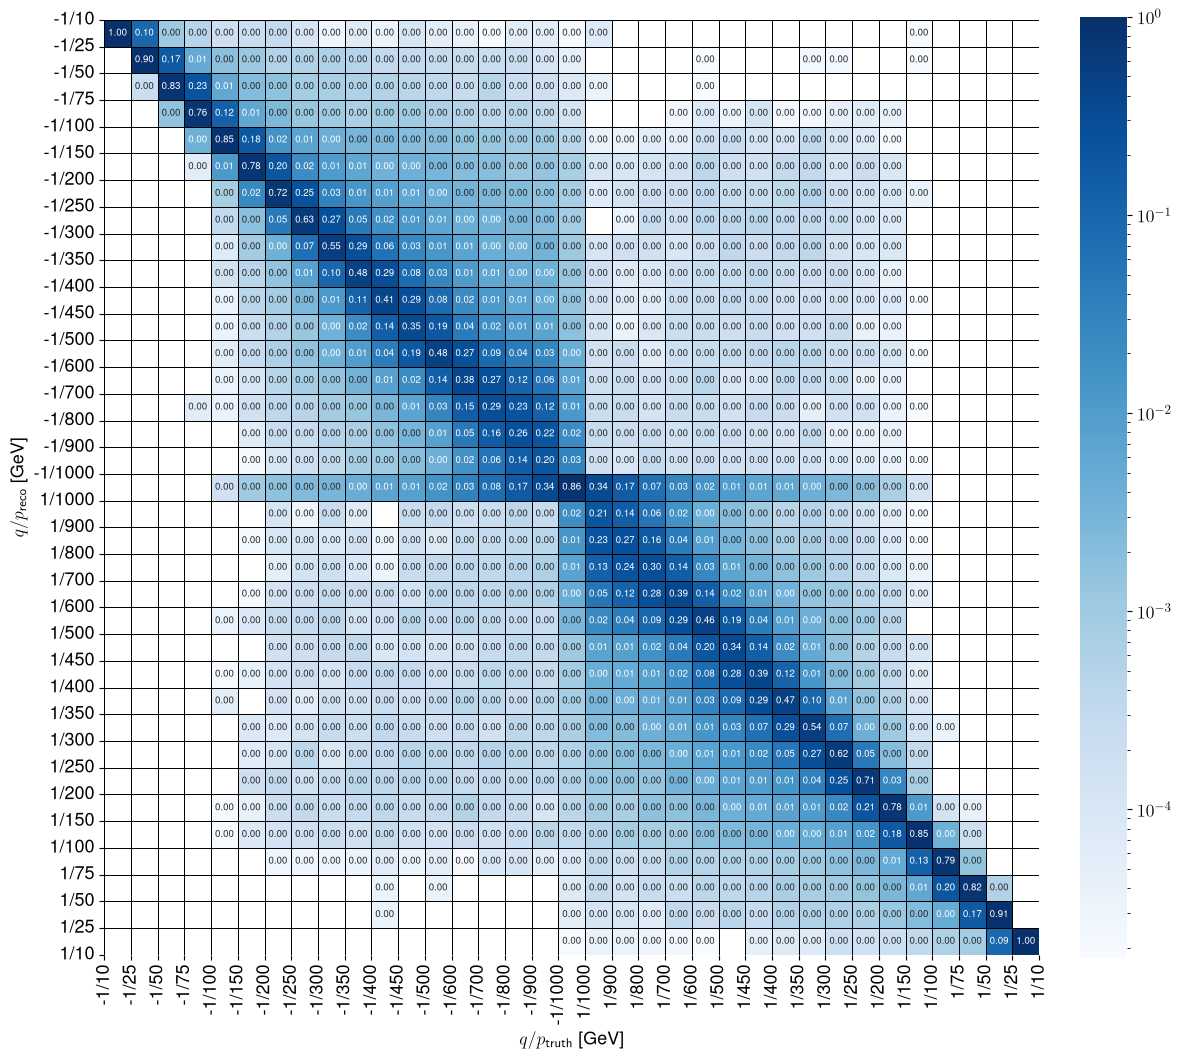

In [123]:
plot_migration_matrix(
    mu_mig,
    xlabel=truth_label,
    ylabel=reco_label,
    norm="log",
    fontsize=7,
    xedges=edges,
    yedges=edges,
    fraction=True,
    figsize=(12, 12),
    out_path="figures/mig_matrix.pdf",
)

## Initial Guess

In [124]:
# Use pre-fit distribution as initial guess
initial_guess = {"mu": unp.nominal_values(mu_flux)}
initial_guess.update({f"theta_mig_{i}": 1e-5 for i in range(num_bins * num_bins)})
initial_guess.update({f"theta_eff_{i}": 1e-5 for i in range(num_bins)})

## Regularization Strength Scan

In [ ]:
# Find regularization strength tau, which minimizes the global correlation rho.
# Over-regularization (large tau): regularization forces bins to follow each other -> correlated
# Under-regularization (small tau): Bins are coupled through ill-conditioned migration matrix

rho_results_wide = rho_scan(
    meas=unp.nominal_values(mu_flux),
    initial_guess=initial_guess,
    mig=unp.nominal_values(mu_mig),
    mig_unc=unp.std_devs(mu_mig),
    reg_values=np.logspace(-3, 3, 7),
    reg_type="log_curvature",
)

7it [07:39, 65.59s/it]


In [21]:
rho_results_fine = rho_scan(
    meas=unp.nominal_values(mu_flux),
    initial_guess=initial_guess,
    mig=unp.nominal_values(mu_mig),
    mig_unc=unp.std_devs(mu_mig),
    reg_values=np.logspace(0, 2, 10),
    reg_type="log_curvature",
)

10it [10:59, 65.93s/it]


In [46]:
# merge and sort rho-results
rho_results = {
    k: np.hstack([rho_results_wide[k], rho_results_fine[k]])
    for k in rho_results_wide.keys()
}
idx = np.argsort(rho_results["reg_values"])
rho_results["reg_values"] = rho_results["reg_values"][idx]
rho_results["rho_values"] = rho_results["rho_values"][idx]

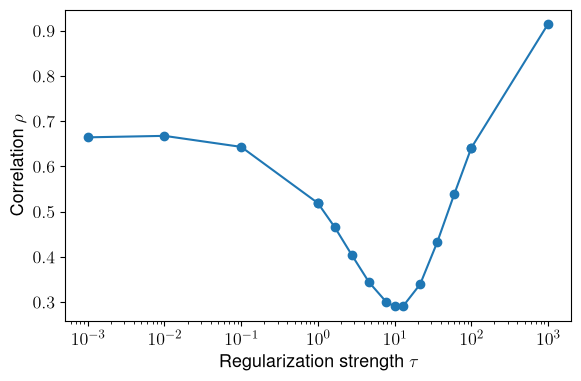

Best regularization strength: 10.0


In [48]:
reg_values = rho_results["reg_values"]
rho_values = rho_results["rho_values"]
plot_rho_scan(reg_values, rho_values)
print(f"Best regularization strength: {reg_values[np.argmin(rho_values)]:.1f}")

## Fit

In [ ]:
# default fit with best regularization strength
default_fit = Fit(
    meas=unp.nominal_values(mu_flux),
    initial_guess=initial_guess,
    mig=unp.nominal_values(mu_mig),
    mig_unc=unp.std_devs(mu_mig),
    regularization=10,
    reg_type="log_curvature",
)
default_fit_values = default_fit.signal_muarray
nominal_fit_values = unp.nominal_values(default_fit_values)

### Regularization Uncertainty

In [160]:
# Calculate systematic uncertainty from regularization:
# Fit with regularization strength scaled by factor 10 and 0.1, and use max. difference
# to nominal fit as uncertainty.

upper_fit = Fit(
    meas=unp.nominal_values(mu_flux),
    initial_guess=initial_guess,
    mig=unp.nominal_values(mu_mig),
    mig_unc=unp.std_devs(mu_mig),
    regularization=100,
    reg_type="log_curvature",
)

lower_fit = Fit(
    meas=unp.nominal_values(mu_flux),
    initial_guess=initial_guess,
    mig=unp.nominal_values(mu_mig),
    mig_unc=unp.std_devs(mu_mig),
    regularization=1,
    reg_type="log_curvature",
)

lower_fit_values = lower_fit.signal_muarray
upper_fit_values = upper_fit.signal_muarray
_lower_unc = np.abs(nominal_fit_values - unp.nominal_values(lower_fit_values))
_upper_unc = np.abs(nominal_fit_values - unp.nominal_values(upper_fit_values))
reg_unc = np.max(np.vstack([_lower_unc, _upper_unc]), axis=0)

# Add fit and regularization uncertainty in quadrature
fit_unc = unp.std_devs(default_fit_values)
unc = np.sqrt(fit_unc**2 + reg_unc**2)

pre_fit_values = mu_flux
post_fit_values = unp.uarray(nominal_fit_values, unc)

In [178]:
qop_bin_labels = [
    f"[{get_str_fraction(lower)}, {get_str_fraction(upper)}]"
    for (lower, upper) in zip(qop_bins[:-1], qop_bins[1:])
]
unc_df = pd.DataFrame(
    {
        "Nominal": nominal_fit_values,
        "Rel. fit unc. [%]": fit_unc / nominal_fit_values * 100,
        "Rel. reg. unc. [%]": reg_unc / nominal_fit_values * 100,
    },
    index=qop_bin_labels,
)
display(unc_df.T)

,"[-1/10, -1/25]","[-1/25, -1/50]","[-1/50, -1/75]","[-1/75, -1/100]","[-1/100, -1/150]","[-1/150, -1/200]","[-1/200, -1/250]","[-1/250, -1/300]","[-1/300, -1/350]","[-1/350, -1/400]",...,"[1/400, 1/350]","[1/350, 1/300]","[1/300, 1/250]","[1/250, 1/200]","[1/200, 1/150]","[1/150, 1/100]","[1/100, 1/75]","[1/75, 1/50]","[1/50, 1/25]","[1/25, 1/10]"
Nominal,110.391364,428.313503,445.022536,387.152011,485.713367,397.99724,263.240817,279.092164,315.859676,247.642113,...,92.255985,112.125502,151.630332,225.560550,367.463181,557.627511,478.128123,580.831684,503.238134,119.388294
Rel. fit unc. [%],10.672024,5.236309,5.396510,5.715519,5.019998,5.76312,7.412485,7.762732,7.797008,9.272784,...,12.240118,10.922223,9.354502,7.592844,5.885268,4.645318,5.150336,4.737923,4.920952,10.381284
Rel. reg. unc. [%],46.689272,19.267275,2.316315,14.178534,7.165983,3.22777,16.493196,0.535939,15.432615,3.335093,...,7.272945,4.477735,3.708144,4.448034,1.970673,8.064308,14.093024,2.156625,16.836131,48.343119


## Plot Unfolded Muon Flux

### Total Flux

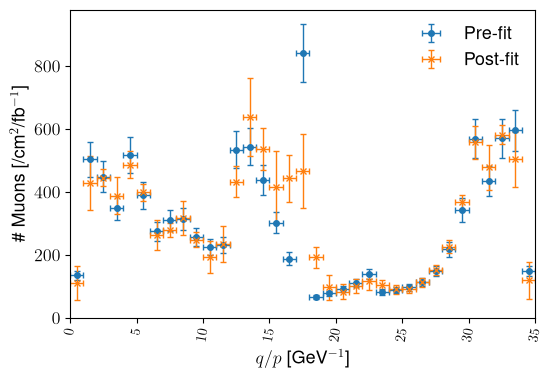

In [127]:
plot_values(
    values=[pre_fit_values, post_fit_values],
    labels=["Pre-fit", "Post-fit"],
    histtypes=["errorbar", "errorbar"],
    edges=np.arange(len(qop_bins)),
    edge_value=qop_bins,
    markers=["o", "x"],
    markersize=4,
    xlabel=r"$q/p$ [GeV$^{-1}$]",
    fontsize=10,
    rotation=80,
)

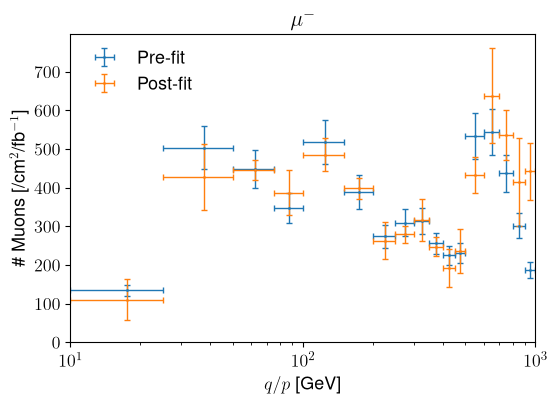

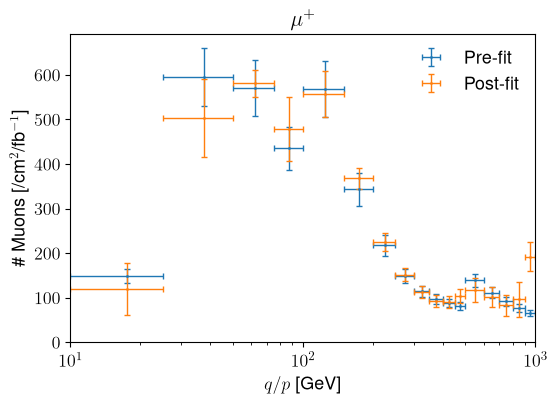

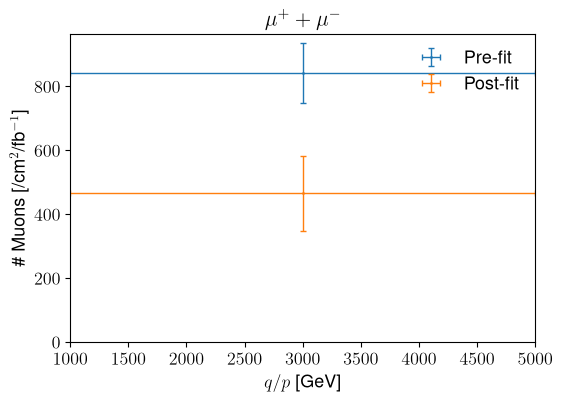

In [157]:
mu_minus_idx = centers < 0
mu_plus_idx = centers > 0
mu_common_idx = centers == 0

pre_fit_mu_minus_flux = pre_fit_values[mu_minus_idx]
post_fit_mu_minus_flux = post_fit_values[mu_minus_idx]

pre_fit_mu_plus_flux = pre_fit_values[mu_plus_idx][::-1]
post_fit_mu_plus_flux = post_fit_values[mu_plus_idx][::-1]

pre_fit_mu_common_flux = pre_fit_values[mu_common_idx]
post_fit_mu_common_flux = post_fit_values[mu_common_idx]

# Neg. charged muons
plot_values(
    values=[pre_fit_mu_minus_flux, post_fit_mu_minus_flux],
    labels=["Pre-fit", "Post-fit"],
    histtypes=["errorbar", "errorbar"],
    edges=momentum_bins[:-1],
    title=r"$\mu^{-}$",
    xlabel=r"$q/p$ [GeV]",
    xscale="log",
    # yscale="log",
    # ylim=(5e1, 1000),
)

# Pos. charged muons
plot_values(
    values=[pre_fit_mu_plus_flux, post_fit_mu_plus_flux],
    labels=["Pre-fit", "Post-fit"],
    histtypes=["errorbar", "errorbar"],
    edges=momentum_bins[:-1],
    title=r"$\mu^{+}$",
    xlabel=r"$q/p$ [GeV]",
    xscale="log",
    # yscale="log",
    # ylim=(5e1, 1000),
)

# Common bin
plot_values(
    values=[pre_fit_mu_common_flux, post_fit_mu_common_flux],
    labels=["Pre-fit", "Post-fit"],
    histtypes=["errorbar", "errorbar"],
    edges=[1000, 5000],
    xlabel=r"$q/p$ [GeV]",
    title=r"$\mu^{+} + \mu^{-}$",
    # ylim=(1e-2, 100),
    # xscale="log",
    # yscale="log",
)

### Normalized Flux

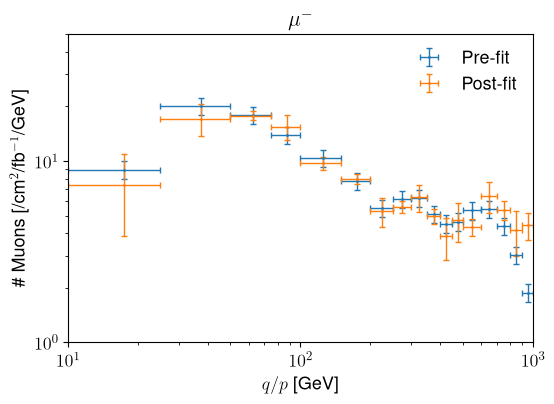

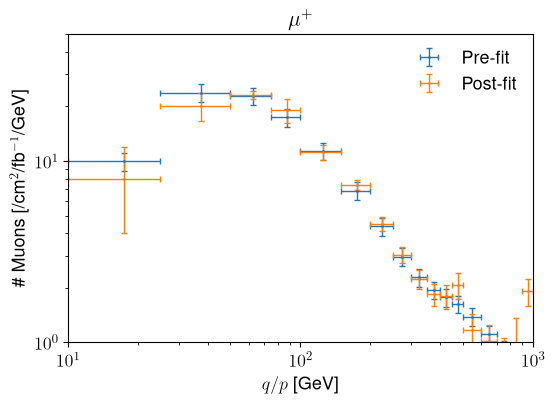

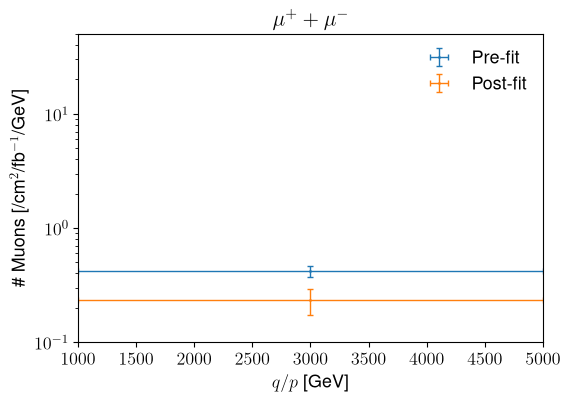

In [150]:
_momentum_bins = momentum_bins[:-1]  # remove last bin
_momentum_widths = _momentum_bins[1:] - _momentum_bins[:-1]

norm_pre_fit_mu_minus_flux = pre_fit_mu_minus_flux / _momentum_widths
norm_post_fit_mu_minus_flux = post_fit_mu_minus_flux / _momentum_widths

norm_pre_fit_mu_plus_flux = pre_fit_mu_plus_flux / _momentum_widths
norm_post_fit_mu_plus_flux = post_fit_mu_plus_flux / _momentum_widths

# TODO chose physically motivated bin width for high-energy bin
common_bin_width = 2000  # GeV
norm_pre_fit_mu_common_flux = pre_fit_mu_common_flux / common_bin_width
norm_post_fit_mu_common_flux = post_fit_mu_common_flux / common_bin_width

# Neg. charged muons
plot_values(
    values=[norm_pre_fit_mu_minus_flux, norm_post_fit_mu_minus_flux],
    labels=["Pre-fit", "Post-fit"],
    histtypes=["errorbar", "errorbar"],
    edges=momentum_bins[:-1],
    title=r"$\mu^{-}$",
    xlabel=r"$q/p$ [GeV]",
    ylabel=r"\# Muons [/cm$^2$/fb$^{-1}$/GeV]",
    xscale="log",
    yscale="log",
    ylim=(1, 50),
)

# Pos. charged muons
plot_values(
    values=[norm_pre_fit_mu_plus_flux, norm_post_fit_mu_plus_flux],
    labels=["Pre-fit", "Post-fit"],
    histtypes=["errorbar", "errorbar"],
    edges=momentum_bins[:-1],
    title=r"$\mu^{+}$",
    xlabel=r"$q/p$ [GeV]",
    ylabel=r"\# Muons [/cm$^2$/fb$^{-1}$/GeV]",
    xscale="log",
    yscale="log",
    ylim=(1, 50),
)

# Common bin
plot_values(
    values=[norm_pre_fit_mu_common_flux, norm_post_fit_mu_common_flux],
    labels=["Pre-fit", "Post-fit"],
    histtypes=["errorbar", "errorbar"],
    edges=[1000, 5000],
    xlabel=r"$q/p$ [GeV]",
    ylabel=r"\# Muons [/cm$^2$/fb$^{-1}$/GeV]",
    title=r"$\mu^{+} + \mu^{-}$",
    # xscale="log",
    yscale="log",
    ylim=(0.1, 50),
)

## Iminuit output

In [182]:
default_fit.m.params

,Name,Value,Hesse Error,Minos Error-,Minos Error+,Limit-,Limit+,Fixed
0,mu_0,110,11,-11,12,0,,
1,mu_1,428,22,-22,22,0,,
2,mu_2,445,24,-23,24,0,,
3,mu_3,387,22,-21,22,0,,
4,mu_4,486,24,-24,24,0,,
5,mu_5,398,23,-22,23,0,,
6,mu_6,263,19,-19,20,0,,
7,mu_7,279,21,-21,22,0,,
8,mu_8,316,24,-24,25,0,,
9,mu_9,248,22,-22,23,0,,
